In [ ]:
from project.util.device import get_available_acc
%cd ..

In [71]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.util.transforms import Difference
from project.util.data import ReplayMemoryData
from project.util.denoisers import MedianFilter, GaussianFilter
from project.util.device import get_available_acc
from project.models import EDMLuomen, EDMMauMau

In [82]:
PATH = os.path.join("checkpoints", "diff", "Fern", "Difference", "Breakout.pt")
DATA = os.path.join("checkpoints", "memory", "Breakout.pt")
SIGMA = 0.1

In [73]:
device = get_available_acc()

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    Difference(),
    transforms.Normalize(0.5, 0.5),
])

In [ ]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=1_000
)

In [83]:
median = MedianFilter(kernel_size=3)
gaussian = GaussianFilter(sigma=0.5)
model = EDMLuomen.from_checkpoint(PATH, device, sigma_noise=SIGMA, N=8).to(device)
model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA).to(device)

In [84]:
x = torch.zeros((4, 7, 88, 88))

for i in range(0, 4):
    x[i] = data[i]

x_noisy = x + SIGMA * torch.randn_like(x)
x_median = median.denoise(x_noisy)
x_gaussian = gaussian.denoise(x_noisy)
x_naive = model_naive.denoise(x_noisy.to(device))
x_dynamic = model.denoise(x_noisy.to(device))

100%|██████████| 2/2 [00:00<00:00,  6.90it/s]


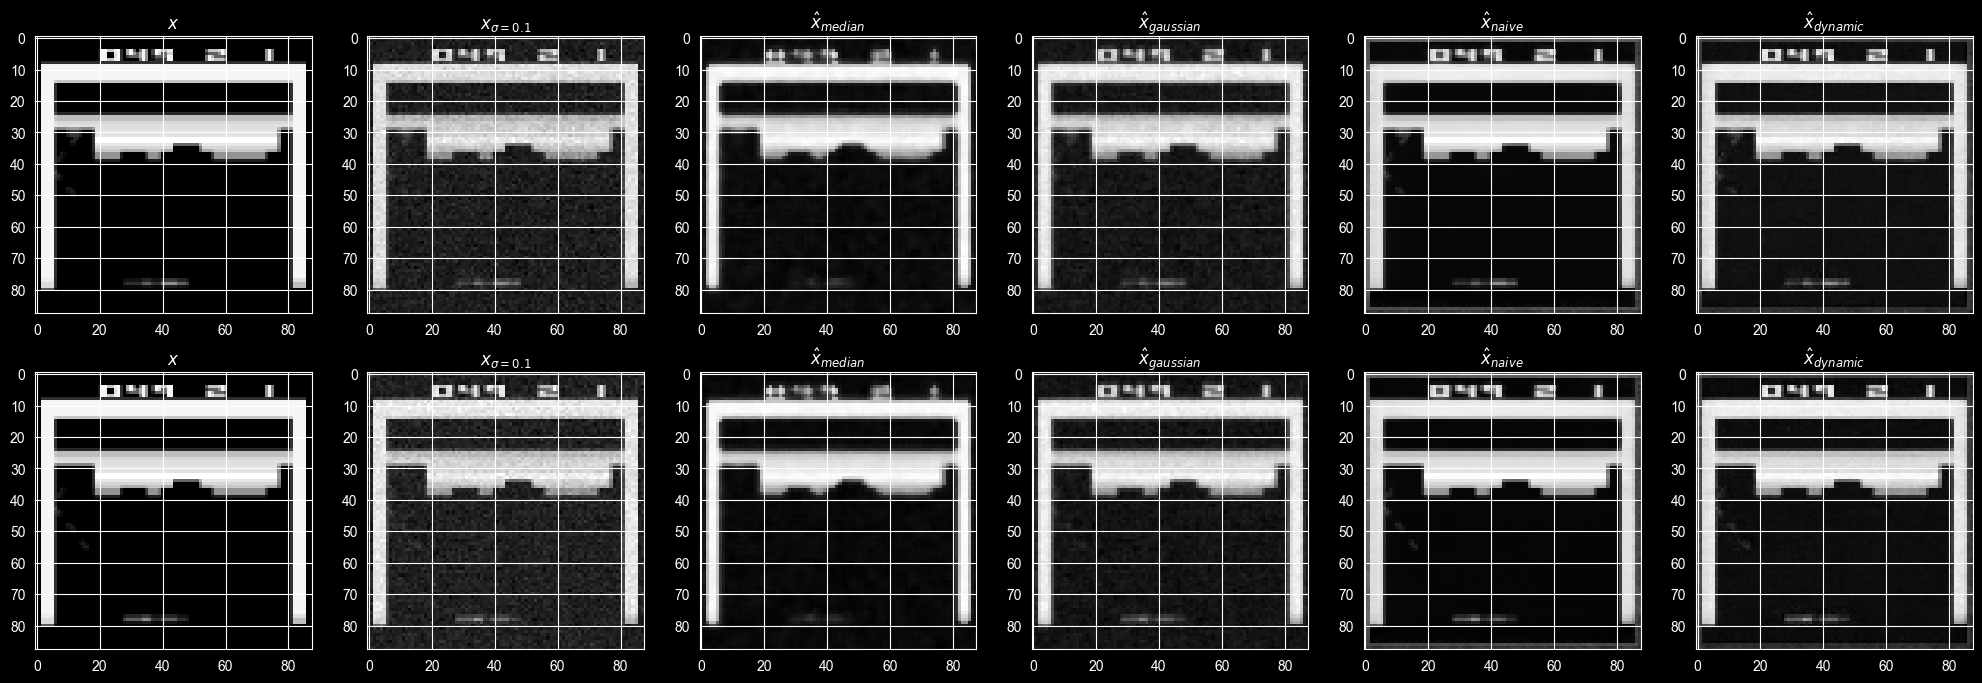

In [86]:
fig, axis = plt.subplots(2, 6, figsize=(25, 8))

for i in range(2):
    axis[i, 0].imshow(x[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 1].imshow(x_noisy[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 2].imshow(x_median[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 3].imshow(x_gaussian[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 4].imshow(x_naive[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 5].imshow(x_dynamic[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 0].set_title("$x$")
    axis[i, 1].set_title("$x_{\\sigma = " + f"{SIGMA}" + "}$")
    axis[i, 2].set_title("$\\hat{x}_{median}$")
    axis[i, 3].set_title("$\\hat{x}_{gaussian}$")
    axis[i, 4].set_title("$\\hat{x}_{naive}$")
    axis[i, 5].set_title("$\\hat{x}_{dynamic}$")

plt.show()